# <center>Motivation</center>


class 1 - diabetes

class 0 - health


## 1) Importing libraries

In [77]:
import polars as pl

from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt

from functions import plots, statistics
from pathlib import Path

import joblib

from time import time

## 2) Reading dataset

In [78]:
random_state = 1
primary_color = "#1c3148"
secondary_color = "#c56715"


### 2.1) Importing data

In [79]:
dataset = pl.read_csv(
    source = "./data/diabetes_data.csv",
    separator = ";"
)

print(dataset.shape)
dataset.head(2)

(520, 17)


age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
40,"""Male""",0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
58,"""Male""",0,0,0,1,0,0,1,0,0,0,1,0,1,0,1


### 2.2) Data overview

#### 2.2.1) Overall

In [80]:
dataset.describe()

statistic,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",520.0,"""520""",520.0,520.0,520.0,520.0,520.0,520.0,520.0,520.0,520.0,520.0,520.0,520.0,520.0,520.0,520.0
"""null_count""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",48.028846,null,0.496154,0.448077,0.417308,0.586538,0.455769,0.223077,0.448077,0.486538,0.242308,0.459615,0.430769,0.375,0.344231,0.169231,0.615385
"""std""",12.151466,null,0.500467,0.497776,0.493589,0.492928,0.498519,0.41671,0.497776,0.5003,0.428892,0.498846,0.495661,0.484589,0.475574,0.375317,0.486973
"""min""",16.0,"""Female""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",39.0,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",48.0,null,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
"""75%""",57.0,null,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0
"""max""",90.0,"""Male""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


#### 2.2.2) Correcting <code>dtypes</code>

In [81]:
boolean_columns = ['polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'class']

dataset = dataset.with_columns(
    [
        pl.col(column).cast(pl.Boolean) for column in boolean_columns
    ]
)

dataset = dataset.with_columns(
    pl.col("gender").cast(pl.Enum(categories = ["Male", "Female"])),
    pl.col("age").cast(pl.Int8)
)

print(f"Dataset new size: {dataset.estimated_size(unit = 'bytes')} bytes")
print(dataset.shape)
dataset.head(2)

Dataset new size: 2030 bytes
(520, 17)


age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
i8,enum,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool
40,"""Male""",false,true,false,true,false,false,false,true,false,true,false,true,true,true,true
58,"""Male""",false,false,false,true,false,false,true,false,false,false,true,false,true,false,true


### 2.3) Plots

#### 2.3.1) Numerical

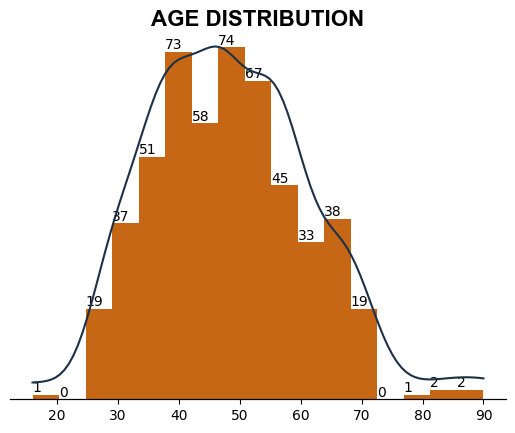

In [82]:
fig, ax = plt.subplots()


plots.plot_histogram(
    ax = ax,
    values = dataset["age"],
    title = {
        "text" : "AGE DISTRIBUTION",
        "size": 16
    },
    color = secondary_color,
    labels = "age",
    tooltip = {
        "horizontalalignment": "left",
        "verticalalignment": "bottom",
    },
    kde = {
        "color": primary_color
    }
)

plt.show()

#### 2.3.2) Categorical

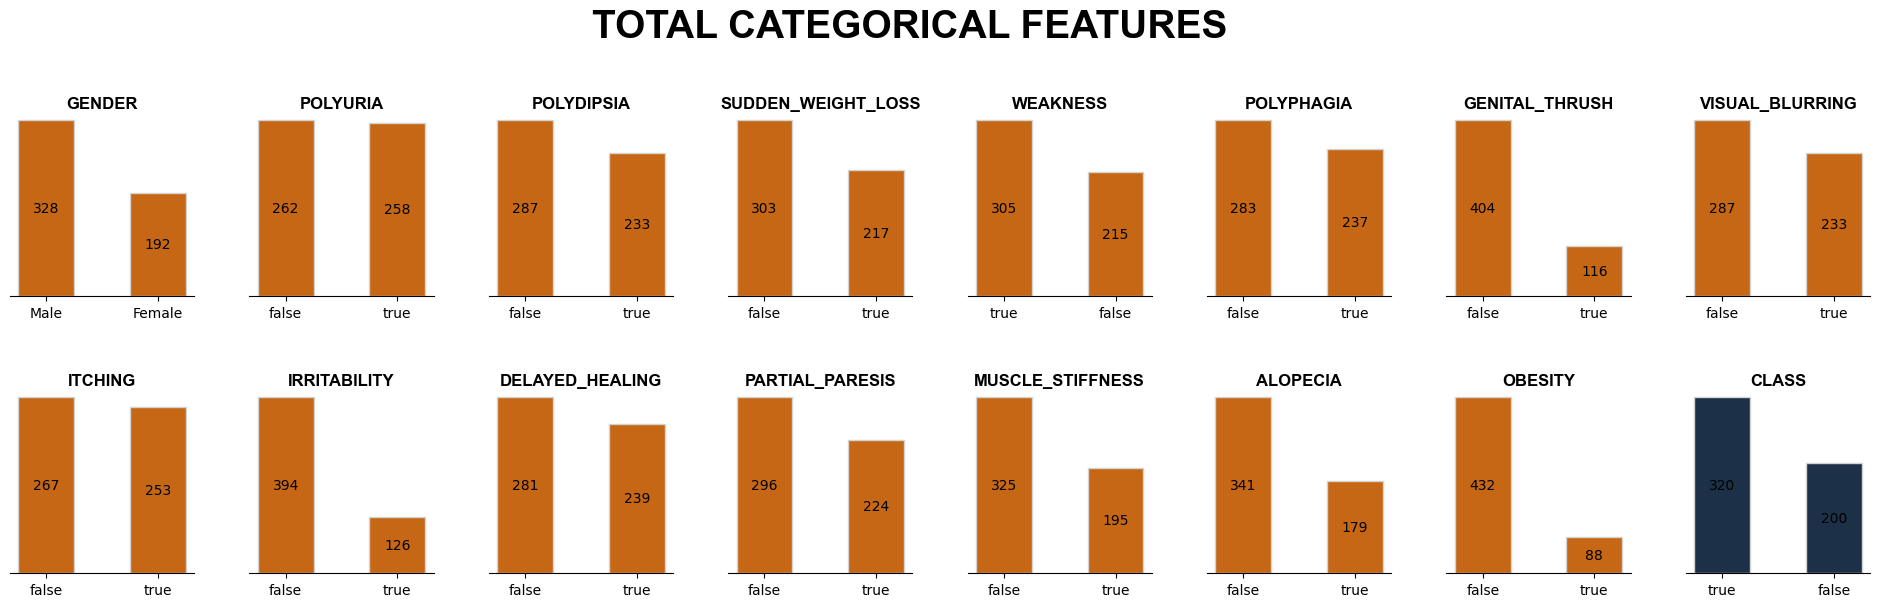

In [83]:
columns = [ 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity', 'class']
colors = [secondary_color]*15 + [primary_color]

fig, axs = plt.subplots(
    nrows = 2,
    ncols = 8,
    figsize = (24, 6),
    gridspec_kw = {
        "hspace": .5,
        "wspace": .3
    }
)

axs = axs.flatten()

for index, column in enumerate(columns):

    plot_df = dataset.group_by(
        column
    ).agg(
        pl.col(column).len().alias("TOTAL")
    ).with_columns(
        pl.col(column).cast(pl.String)
    ).sort(
        by = "TOTAL",
        descending = True
    )

    plots.plot_bar(
        ax = axs[index],
        x_values = plot_df[column],
        y_values = plot_df["TOTAL"],
        title = {
            "text": f"{column}".upper()
        },
        x_label = {
            "text": "",
        },

        y_label=  {
            "text": ""
        },
        colors = colors[index],
        legends = column

    )

plt.suptitle(
    t = "TOTAL CATEGORICAL FEATURES",
    fontsize = "28",
    y = 1.05,
    fontweight = "bold",
    fontfamily = "arial"
)
plt.show()

#### 2.3.3) Correlation

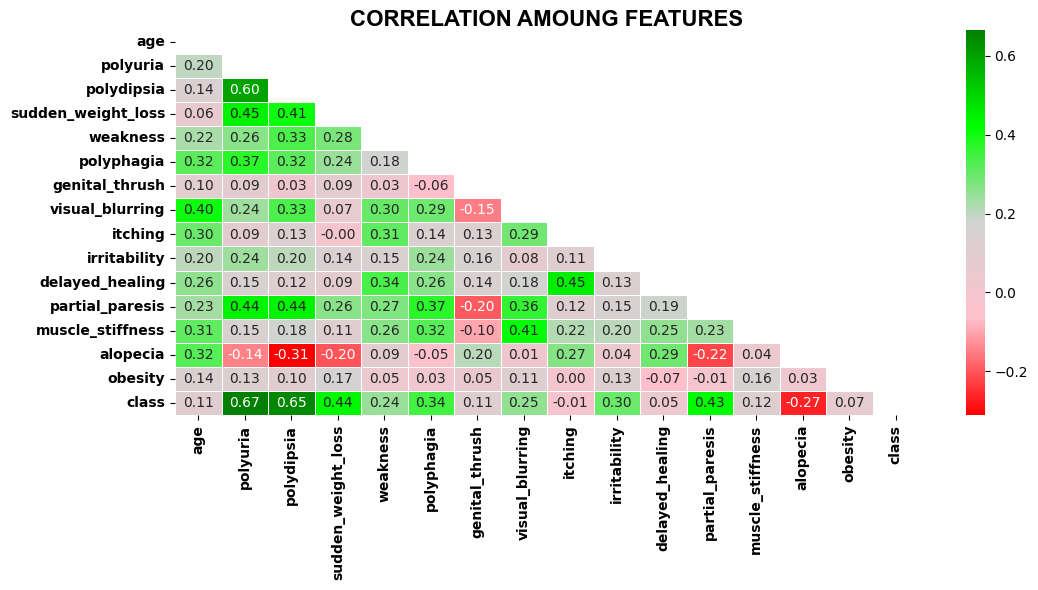

In [84]:
fig, ax = plt.subplots(
    figsize = (12, 5)
)

plots.plot_heatmap(
    ax = ax,
    corr_dataset = dataset.drop("gender").corr(),
    title = {
        "text": "CORRELATION AMOUNG FEATURES",
        "size": 16,
    },
    hayticks = "right",
    xticksrotation = 90
)

plt.show()

## 3) Preparing data

### 3.1) Removing high correlation columns

In [85]:
dataset = dataset.drop(
    ["polyuria", "polydipsia"]
)

### 3.2) Preprocessing

In [86]:
one_hot_encoder = OneHotEncoder()
standard_scaler = StandardScaler()

pre_processing = ColumnTransformer(
    transformers = [
        ("gender_encoder", one_hot_encoder, ["gender"]),
        ("age_encoder", standard_scaler, ["age"])
    ]
)


### 3.3) Splinting the data

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    dataset.drop("class"), dataset["class"],
    test_size = 0.2,
    random_state = random_state,
    stratify = dataset["class"]
)

print(
    X_train.shape, X_test.shape, y_train.shape, y_test.shape
)

(416, 14) (104, 14) (416,) (104,)


## 4) Training

### 4.1) Setting algorithms

In [88]:
models = [

    {
        "name": "GaussianNB",
        "model": GaussianNB(),
        "paramns": {
            "model__var_smoothing": [1E-5, 1E-6, 1E-7, 1E-8, 1E-9, 1E-10, 1E-11],
        },
        "x_train": X_train,
        "y_train": y_train
    },
    
    {
        "name": "RidgeClassifier",
        "model": RidgeClassifier(),
        "paramns": {
            "model__alpha": [.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 5],
            "model__solver": ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
        },
        "x_train": X_train,
        "y_train": y_train
    },

    {
        "name": "RandomForestClassifier",
        "model": RandomForestClassifier(),
        "paramns": {
            "model__n_estimators": [10, 25, 50, 100, 150, 200, 250],
            "model__max_features": ['sqrt', 'log2'],
            "model__criterion": ['gini', 'entropy', 'log_loss'],
            "model__class_weight": ['balanced', None],
        },
        "x_train": X_train,
        "y_train": y_train
    },

    {
        "name": "DecisionTreeClassifier",
        "model": DecisionTreeClassifier(),
        "paramns": {
            "model__criterion": ['gini', 'entropy', 'log_loss'],
            "model__class_weight": ['balanced', None],
        },
        "x_train": X_train,
        "y_train": y_train
    },

    {
        "name": "ExtraTreeClassifier",
        "model": ExtraTreeClassifier(),
        "paramns": {
            "model__criterion": ['gini', 'entropy', 'log_loss'],
            "model__class_weight": ['balanced', None],
        },
        "x_train": X_train,
        "y_train": y_train
    },

    {
        "name": "SVC",
        "model": SVC(),
        "paramns": {
            "model__C": [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2],
            "model__kernel": ['linear', 'poly', 'rbf', 'sigmoid'],
            "model__class_weight": ['balanced', None]
        },
        "x_train": X_train,
        "y_train": y_train
    },

    {
        "name": "KNeighborsClassifier",
        "model": KNeighborsClassifier(),
        "paramns": {
            "model__n_neighbors": [5, 10, 15, 20],
            "model__weights": ['uniform', 'distance'],
            "model__p": [1, 2]
        },
        "x_train": X_train,
        "y_train": y_train
    },

    {
        "name": "MLPClassifier",
        "model": MLPClassifier(max_iter = 200, tol = 0.001),
        "paramns": {
            "model__hidden_layer_sizes": [
                (32, 32, 32, ),
                (32, 32, 16, ),
                (32, 32, 8, ),
                (32, 16, 16, ),
                (32, 16, 8, ),
                (32, 8, 8, ),
                (16, 16, 16, ),
                (16, 16, 8, ),
                (16, 8, 8, ),
                (8, 8, 8, ),
                (32, 32, ),
                (16, 16, ),
                (8, 8, ),
                (32, ),
                (16, ),
                (8, ),
            ],
            "model__activation": ['relu', 'tanh'],
            "model__batch_size": [8, 16, 32],
        },
        "x_train": X_train,
        "y_train": y_train
    },
]

### 4.2) GridSearch

In [89]:
for model in models:
    
    pipeline = Pipeline(
        steps = [
            ("pre_processing", pre_processing),
            ("model", model["model"])
        ]
    )

    estimator = GridSearchCV(
        estimator = pipeline,
        param_grid = model["paramns"],
        n_jobs = -1,
        cv = 5,
        error_score = "raise",
        scoring = "f1",
        refit = True
    )

    estimator.fit(
        X = model['x_train'],
        y = model['y_train']
    )

    joblib.dump(
        filename = f"./models/tests/{model['name']}.joblib",
        value = estimator.best_estimator_
    )

## 5) Evaluating

### 5.1) Confusion matrices

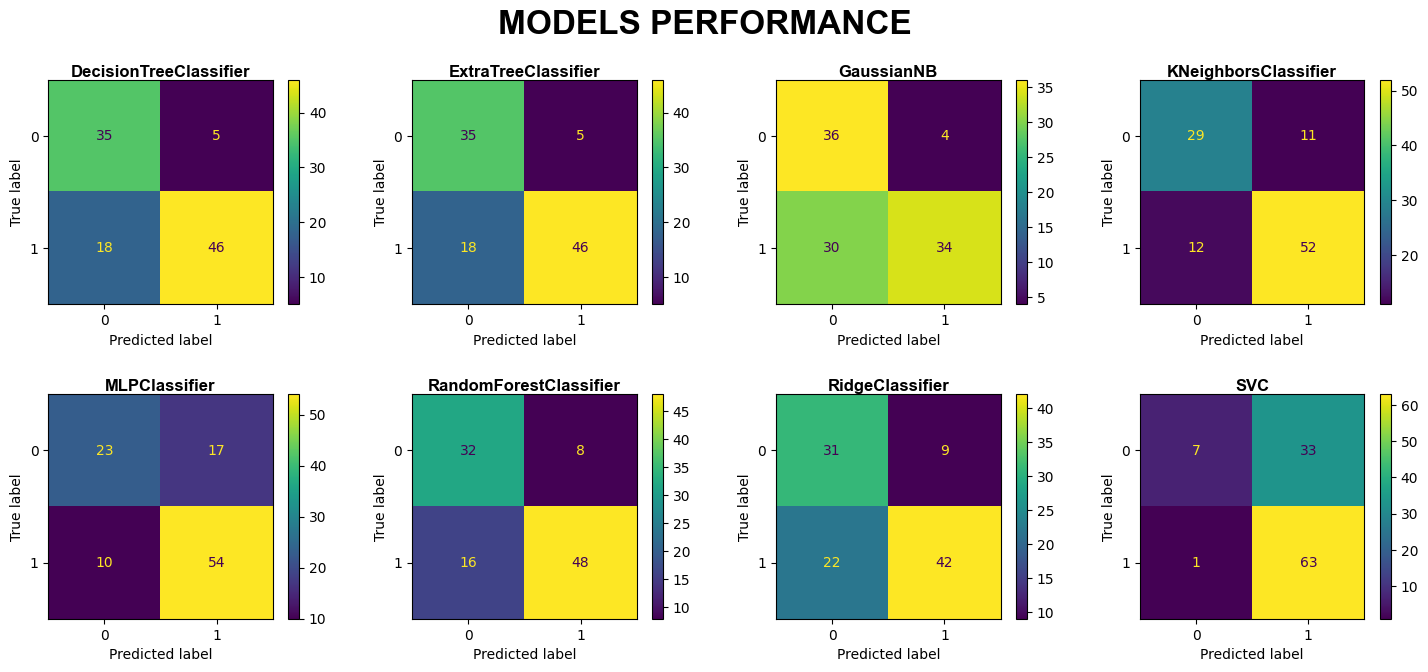

In [91]:
trained_models = []

for archive in Path("./models/tests/").iterdir():

    trained_models.append(
        {
            "name": archive.name.replace(".joblib", ""),
            "model": joblib.load(
                filename = archive
            )
        }
    )

fig, axs = plt.subplots(
    ncols = 4,
    nrows = 2,
    figsize = (18, 7),
    gridspec_kw = {
        "hspace": 0.4
    }
)

axs = axs.flatten()

metrics = {
    "model": [],
    "f1": [],
    "accuracy": [],
    "recall": [],
    "time": []
}

for index, model in enumerate(trained_models):

    start_time = time()
    prediction = model["model"].predict(
        X = X_test
    )
    end_time = time()

    metrics["model"].append(model["name"])
    metrics["time"].append(end_time - start_time)
    metrics["f1"].append(
        f1_score(
            y_true = y_test,
            y_pred = prediction
        )
    )
    metrics["accuracy"].append(
        accuracy_score(
            y_true = y_test,
            y_pred = prediction        
        )
    )
    metrics["recall"].append(
        recall_score(
            y_true = y_test,
            y_pred = prediction
        )
    )

    plots.plot_confusion_matrix(
        ax = axs[index],
        y_true = y_test,
        y_pred = prediction,
        title = {
            "text": model["name"]
        }
    )

plt.suptitle(
    t = "MODELS PERFORMANCE",
    fontsize = 24,
    fontweight = "bold",
    fontfamily = "arial"
)
plt.show()

### 5.2) Overall metrics

#### 5.2.1) Creating dataset

In [94]:
metrics_df = pl.DataFrame(
    metrics
)

metrics_df = metrics_df.with_columns(
    (
        pl.col("f1")*2 + pl.col("accuracy")*3 + pl.col("recall") - 5*pl.col("time")
    ).alias("overall")
).sort(
    by = "overall",
    descending = True
)


metrics_df

model,f1,accuracy,recall,time,overall
str,f64,f64,f64,f64,f64
"""KNeighborsClassifier""",0.818898,0.778846,0.8125,0.0,4.786834
"""MLPClassifier""",0.8,0.740385,0.84375,0.0,4.664904
"""DecisionTreeClassifier""",0.8,0.778846,0.71875,0.0,4.655288
"""RandomForestClassifier""",0.8,0.769231,0.75,0.001422,4.65058
"""ExtraTreeClassifier""",0.8,0.778846,0.71875,0.011214,4.59922
"""SVC""",0.7875,0.673077,0.984375,0.0,4.578606
"""RidgeClassifier""",0.730435,0.701923,0.65625,0.0,4.222889
"""GaussianNB""",0.666667,0.673077,0.53125,0.0,3.883814


#### 5.2.2) Plots

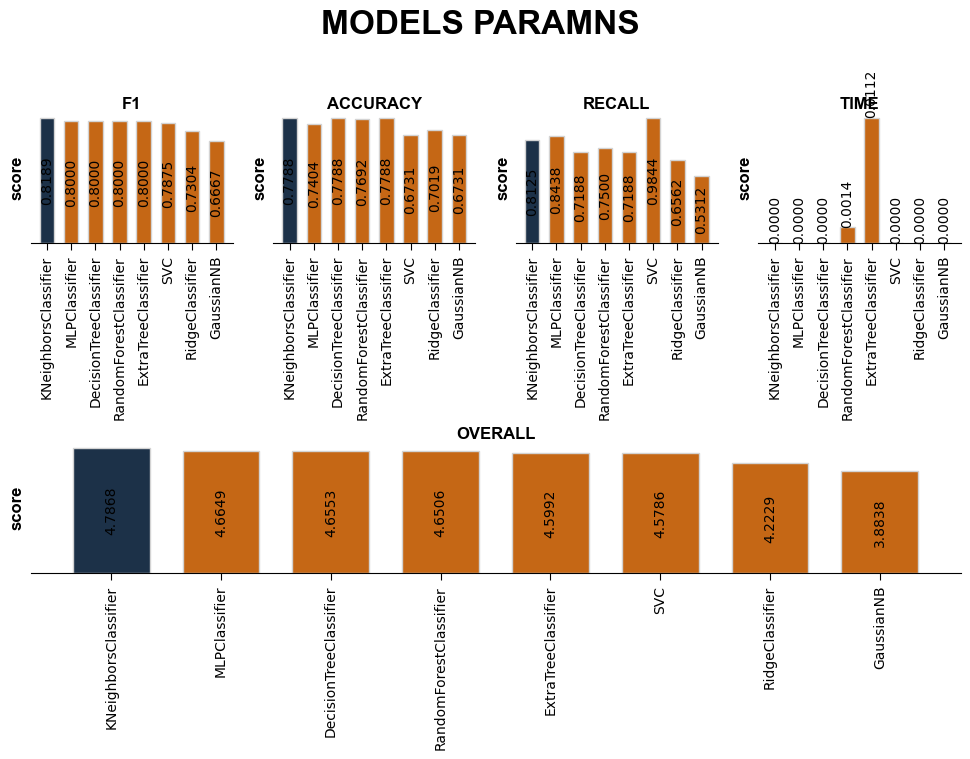

In [95]:
columns = ["f1", "accuracy", "recall", "time",]

fig, axs = plt.subplot_mosaic(
    mosaic = [columns, ["overall", "overall", "overall", "overall"]],
    figsize = (12, 6),
    gridspec_kw = {
        "hspace": 1.5
    }
)


for index, column in enumerate(columns):

    plots.plot_bar(
        ax = axs[column],
        x_values = metrics_df["model"],
        y_values = metrics_df[column],
        colors = [primary_color] + [secondary_color]*15,
        legends = column,
        title = {
            "text": column.upper()
        },
        x_label = {
            "text": "",
        },
        y_label = {
            "text": "score"
        },
        width = 0.6,
        tooltip_rotation = 90,
        tooltip_align = ["center", "center", "center", "edge"][index],
        formater = "{:,.4f}",
    )

    axs[column].tick_params(axis='x', labelrotation = 90, size = 5)

plots.plot_bar(
    ax = axs["overall"],
    x_values = metrics_df["model"],
    y_values = metrics_df["overall"],
    colors = [primary_color, secondary_color, secondary_color, secondary_color, secondary_color, secondary_color, secondary_color, secondary_color, secondary_color],
    legends = "overall",
    title = {
        "text": "overall".upper()
    },
    x_label = {
        "text": "",
    },
    y_label = {
        "text": "score"
    },
    width = 0.7,
    tooltip_rotation = 90,
    tooltip_align = "center",
    formater = "{:,.4f}",
)
axs["overall"].tick_params(axis='x', labelrotation = 90, size = 5)

plt.suptitle(
    t = "MODELS PARAMNS",
    fontsize = 24,
    y = 1.05,
    fontweight = "bold",
    fontfamily = "arial"
)

plt.show()

## 6) Choosing model

In [98]:
best_model = joblib.load(
    filename = f"./models/tests/{metrics_df[0,0]}.joblib"
)

joblib.dump(
    value = best_model,
    filename = "./models/pipeline/diabetes_model.joblib"
)

['./models/pipeline/diabetes_model.joblib']